# File

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("TORUN.csv") # ETO YUNG GINAMIT KONG CSV YA CHINECK Q NA
X = df.drop('HIV_Status', axis=1)
y = df['HIV_Status']

# 1. First split to separate out the unseen TEST set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# 2. Second split to separate Train and Validation from the remaining 80%
# 0.25 x 0.8 = 0.2 (So we end up with 60% Train, 20% Val, 20% Test)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, stratify=y_temp, test_size=0.25, random_state=42
)

In [2]:
df.head(10)

,Sex,Age_Group,Transmission,Healthcare_Access_Friction,Civil_Status,OFW_Status,Chemsex_Engagement,Alcohol_Sex_Risk,PrEP_Awareness,Transactional_Sex,STI_BBV_CoInfection_Any,HIV_Status
0,Female,<15,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
1,Male,15-24,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
2,Male,15-24,Male to Male Sex,2,Single,No,No,No,Yes,No TS,Yes,Reactive
3,Male,15-24,Male to Male Sex,2,Single,No,No,No,No,No TS,Yes,Reactive
4,Male,15-24,Male to Male Sex,2,Single,No,Yes,No,Yes,No TS,No,Reactive
5,Male,15-24,Male to Male/Female Sex,2,Single,No,No,Yes,Yes,Both,No,Reactive
6,Male,25-34,Male to Female Sex,2,Common-Law,No,No,No,No,No TS,No,Reactive
7,Male,25-34,Male to Male Sex,2,Single,No,No,No,Yes,No TS,No,Reactive
8,Male,25-34,Male to Male Sex,2,Single,No,No,No,No,No TS,No,Reactive
9,Male,25-34,Male to Male Sex,2,Single,No,No,Yes,Yes,Paid for sex,Yes,Reactive


# Preprocessing

In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# list num and cat
numeric_features = []
categorical_features = ['Sex','Age_Group','Transmission',
                        'Healthcare_Access_Friction','Civil_Status','OFW_Status','Chemsex_Engagement',
                        'Alcohol_Sex_Risk','PrEP_Awareness','Transactional_Sex','STI_BBV_CoInfection_Any']

# 2. proprocessor
preprocessor = ColumnTransformer(
    transformers=[
        # Apply StandardScaler to numeric columns
        ('num', StandardScaler(), numeric_features),

        # Apply OneHotEncoder to categorical columns
        # handle_unknown='ignore' ensures the code won't crash if X_test has a category not seen in X_train
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Keep any other columns not listed above (or use 'drop')
)

# 3. Fit and Transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_val_processed = preprocessor.transform(X_val) 


# Convert into DataFrame AND preserve the original index
X_train_processed = pd.DataFrame(X_train_processed, columns=preprocessor.get_feature_names_out(), index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=preprocessor.get_feature_names_out(), index=X_test.index)

#Convert validation set to DataFrame
X_val_processed = pd.DataFrame(
    X_val_processed,
    columns=preprocessor.get_feature_names_out(),
    index=X_val.index
)


# Dealing with y columns
mapping = {'Non-Reactive': 0, 'Reactive': 1}
y_train_processed = y_train.map(mapping)
y_test_processed = y_test.map(mapping)

# ADD THIS LINE: Map the validation labels!
y_val_processed = y_val.map(mapping)

 # MODEL

In [8]:
from sklearn.model_selection import ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    average_precision_score,
    confusion_matrix,           # Added for Specificity
    balanced_accuracy_score,    # Added for Balanced Accuracy
    brier_score_loss            # Added for Brier Score
)
from sklearn.calibration import CalibrationDisplay # Added for Calibration visual
import matplotlib.pyplot as plt

# 1. Define the Hyperparameter Grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100], 
    'penalty': ['l2']             
}

# 2. Setup tracking for the best model
best_val_auprc = -1
best_params_lr = None
best_lr_model = None

print("Tuning Logistic Regression using the Validation Set...")

# 3. Loop through all combinations of hyperparameters
for params in ParameterGrid(param_grid_lr):
    lr = LogisticRegression(
        **params,
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='liblinear'
    )
    
    # Train on the TRAINING set
    lr.fit(X_train_processed, y_train_processed)
    
    # Evaluate on the VALIDATION set
    y_val_probs = lr.predict_proba(X_val_processed)[:, 1]
    val_auprc = average_precision_score(y_val_processed, y_val_probs)
    
    # Save the best model
    if val_auprc > best_val_auprc:
        best_val_auprc = val_auprc
        best_params_lr = params
        best_lr_model = lr

print(f"\nBest Parameters Found: {best_params_lr}")
print(f"Best Validation AUPRC: {best_val_auprc:.4f}")

# 4. Make Final Predictions on the unseen TEST set using the winning model
print("\nEvaluating the best model on the Test Set...")
y_pred_test = best_lr_model.predict(X_test_processed)
y_probs_test = best_lr_model.predict_proba(X_test_processed)[:, 1]

# --- NEW METRICS CALCULATIONS ---

# Extract matrix components to calculate Specificity (True Negative Rate)
tn, fp, fn, tp = confusion_matrix(y_test_processed, y_pred_test).ravel()
specificity = tn / (tn + fp)

# Calculate Balanced Accuracy and Brier Score
bal_acc = balanced_accuracy_score(y_test_processed, y_pred_test)
brier = brier_score_loss(y_test_processed, y_probs_test)

# 5. Final Evaluate
print("\n--- Logistic Regression Final Test Report ---")
print(classification_report(y_test_processed, y_pred_test, target_names=['Non-Reactive', 'Reactive']))
print(f"Test F1-Score:           {f1_score(y_test_processed, y_pred_test):.4f}")
print(f"Test AUPRC:              {average_precision_score(y_test_processed, y_probs_test):.4f}")
print(f"Test Specificity:        {specificity:.4f}")
print(f"Test Balanced Accuracy:  {bal_acc:.4f}")
print(f"Test Brier Score:        {brier:.4f}")


Tuning Logistic Regression using the Validation Set...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalt


Best Parameters Found: {'C': 1, 'penalty': 'l2'}
Best Validation AUPRC: 0.1319

Evaluating the best model on the Test Set...

--- Logistic Regression Final Test Report ---
              precision    recall  f1-score   support

Non-Reactive       0.94      0.72      0.82     60291
    Reactive       0.12      0.48      0.20      4973

    accuracy                           0.70     65264
   macro avg       0.53      0.60      0.51     65264
weighted avg       0.88      0.70      0.77     65264

Test F1-Score:           0.1969
Test AUPRC:              0.1271
Test Specificity:        0.7230
Test Balanced Accuracy:  0.5995
Test Brier Score:        0.2342


# Threshold Moving 

In [9]:
import numpy as np
from sklearn.metrics import (
    f1_score, 
    precision_score, 
    recall_score,
    precision_recall_curve,
    confusion_matrix,           # Added
    balanced_accuracy_score,    # Added
    brier_score_loss            # Added
)

# ---------------------------------------------------------
# STEP 1: FIND THE BEST THRESHOLD ON THE *VALIDATION* SET
# ---------------------------------------------------------

# Get probabilities for the Validation set (Class 1)
lr_probs_val = best_lr_model.predict_proba(X_val_processed)[:, 1]

# Vectorized tool to get all possible thresholds
precisions_val, recalls_val, thresholds_val = precision_recall_curve(y_val_processed, lr_probs_val)

# Calculate F1 for every threshold at once
f1_scores_val = 2 * (precisions_val * recalls_val) / (precisions_val + recalls_val + 1e-8)

# Locate the best threshold
best_idx = np.argmax(f1_scores_val[:-1])
best_threshold_lr = thresholds_val[best_idx]

print(f"Optimal Logistic Threshold (Validation): {best_threshold_lr:.4f}")

# ---------------------------------------------------------
# STEP 2: EVALUATE ON THE *TEST* SET (THE FINAL EXAM)
# ---------------------------------------------------------

# Get probabilities for the Test set
lr_probs_test = best_lr_model.predict_proba(X_test_processed)[:, 1]

# Apply the threshold found in Step 1
optimal_preds_test = (lr_probs_test >= best_threshold_lr).astype(int)

# --- NEW METRICS CALCULATIONS ---
# Extract matrix components to calculate Specificity
tn, fp, fn, tp = confusion_matrix(y_test_processed, optimal_preds_test).ravel()
specificity = tn / (tn + fp)

# Calculate Balanced Accuracy
bal_acc = balanced_accuracy_score(y_test_processed, optimal_preds_test)

# Calculate Brier Score (Note: this uses probabilities, not the thresholded predictions)
brier = brier_score_loss(y_test_processed, lr_probs_test)

# Compare results
print("\n--- LOGISTIC REGRESSION TEST PERFORMANCE (OPTIMIZED THRESHOLD) ---")
print(f"Best F1-Score:           {f1_score(y_test_processed, optimal_preds_test):.4f}")
print(f"Precision:               {precision_score(y_test_processed, optimal_preds_test, zero_division=0):.4f}")
print(f"Recall:                  {recall_score(y_test_processed, optimal_preds_test):.4f}")
print(f"Specificity:             {specificity:.4f}")
print(f"Balanced Accuracy:       {bal_acc:.4f}")
print(f"Brier Score:             {brier:.4f}")

Optimal Logistic Threshold (Validation): 0.5869

--- LOGISTIC REGRESSION TEST PERFORMANCE (OPTIMIZED THRESHOLD) ---
Best F1-Score:           0.1979
Precision:               0.1284
Recall:                  0.4309
Specificity:             0.7587
Balanced Accuracy:       0.5948
Brier Score:             0.2342


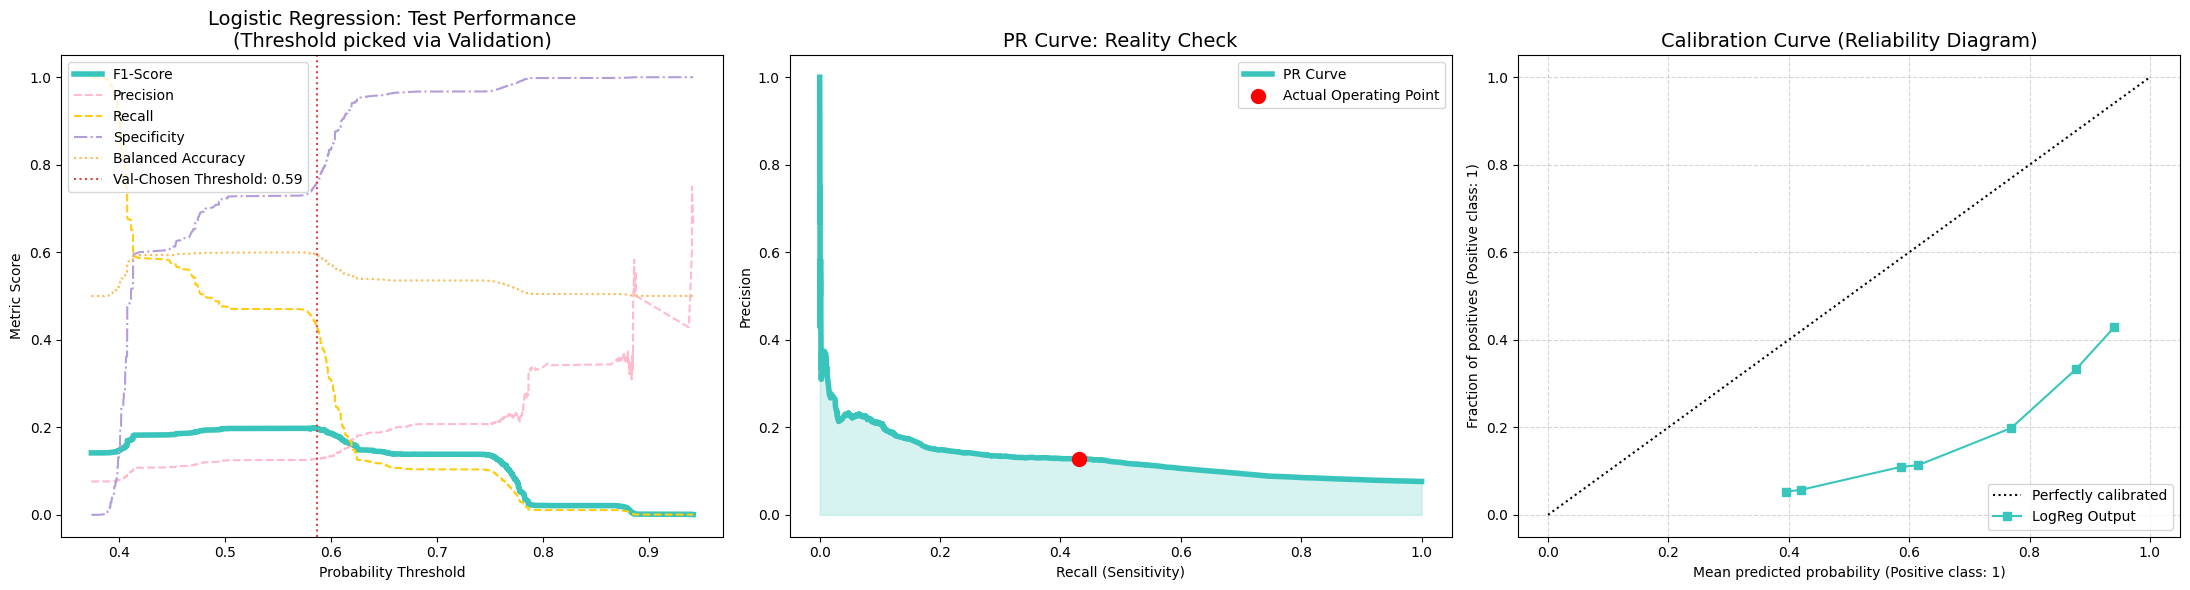

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    confusion_matrix
)
from sklearn.calibration import CalibrationDisplay

# --- 1. SETUP DATA ---
# Get Validation Probs to FIND the threshold
val_probs = best_lr_model.predict_proba(X_val_processed)[:, 1]
p_v, r_v, t_v = precision_recall_curve(y_val_processed, val_probs)
f1_v = 2 * (p_v * r_v) / (p_v + r_v + 1e-8)
best_threshold_lr = t_v[np.argmax(f1_v[:-1])] # THIS is the "Golden" number

# Get Test Probs to PLOT the final results
lr_probs_test = best_lr_model.predict_proba(X_test_processed)[:, 1]
precision_lr, recall_lr, pr_thresholds_lr = precision_recall_curve(y_test_processed, lr_probs_test)

# --- NEW METRICS FOR PLOT 1 ---
test_f1s = 2 * (precision_lr * recall_lr) / (precision_lr + recall_lr + 1e-8)

# Calculate Specificity and Balanced Accuracy across all thresholds
test_specificity = []
test_bal_acc = []

for t in pr_thresholds_lr:
    preds = (lr_probs_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_processed, preds).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0 # Sensitivity is Recall
    
    test_specificity.append(spec)
    test_bal_acc.append((spec + sens) / 2)

# --- 2. Create the Figure (Expanded to 3 panels) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# --- PLOT 1: Threshold vs Metrics (Calculated on Test Set) ---
ax1.plot(pr_thresholds_lr, test_f1s[:-1], label='F1-Score', color='#39C5BB', linewidth=4)
ax1.plot(pr_thresholds_lr, precision_lr[:-1], label='Precision', color='#FFBACC', linestyle='--')
ax1.plot(pr_thresholds_lr, recall_lr[:-1], label='Recall', color='#FFCC11', linestyle='--')

# Add the new metrics
ax1.plot(pr_thresholds_lr, test_specificity, label='Specificity', color='#B39DDB', linestyle='-.')
ax1.plot(pr_thresholds_lr, test_bal_acc, label='Balanced Accuracy', color='#FFB74D', linestyle=':')

# The "Audit" Line
ax1.axvline(best_threshold_lr, color='#DD4444', linestyle=':', 
            label=f'Val-Chosen Threshold: {best_threshold_lr:.2f}')

ax1.set_title("Logistic Regression: Test Performance\n(Threshold picked via Validation)", fontsize=14)
ax1.set_xlabel("Probability Threshold")
ax1.set_ylabel("Metric Score")
ax1.legend()

# --- PLOT 2: Precision-Recall Curve ---
ax2.plot(recall_lr, precision_lr, color='#39C5BB', linewidth=4, label='PR Curve')
ax2.fill_between(recall_lr, 0, precision_lr, color='#39C5BB', alpha=0.2)

# Mark where the VALIDATION threshold falls on the TEST curve
idx_lr = np.argmin(np.abs(pr_thresholds_lr - best_threshold_lr))
ax2.scatter(recall_lr[idx_lr], precision_lr[idx_lr], color='red', s=100, zorder=5, label='Actual Operating Point')

ax2.set_title("PR Curve: Reality Check", fontsize=14)
ax2.set_xlabel("Recall (Sensitivity)")
ax2.set_ylabel("Precision")
ax2.legend()

# --- PLOT 3: Calibration Curve ---
CalibrationDisplay.from_predictions(
    y_test_processed, 
    lr_probs_test, 
    n_bins=10, 
    name="LogReg Output",
    ax=ax3,
    color='#39C5BB'
)
ax3.set_title("Calibration Curve (Reliability Diagram)", fontsize=14)
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# SHAP

In [11]:
import shap

# 1. Initialize the Linear Explainer for Logistic Regression
# Linear models usually need the training data passed in to establish a "baseline"
explainer_lr = shap.LinearExplainer(best_lr_model, X_train_processed)
shap_vals_lr = explainer_lr.shap_values(X_test_processed)

# Unlike Trees (which return [Class 0, Class 1]), LinearExplainer for binary LR
# usually just returns a single array for the positive class.
# We add a quick safety check just in case your specific version returns a list!
if isinstance(shap_vals_lr, list):
    shap_raw_lr = shap_vals_lr[1]
else:
    shap_raw_lr = shap_vals_lr

# Put them in a DataFrame for easy grouping
shap_df_lr = pd.DataFrame(shap_raw_lr, columns=X_test_processed.columns)
grouped_shap_df_lr = shap_df_lr.copy()

# 2. Define the exact prefixes of your One-Hot Encoded columns
categorical_prefixes = ['cat__Sex','cat__Age_Group','cat__Transmission',
                        'cat__Healthcare_Access_Friction','cat__Civil_Status','cat__OFW_Status','cat__Chemsex_Engagement',
                        'cat__Alcohol_Sex_Risk','cat__PrEP_Awareness','cat__Transactional_Sex','cat__STI_BBV_CoInfection_Any']

# 3. Stitch the dummy columns back together!
for prefix in categorical_prefixes:
    # Find all columns that start with this prefix
    dummy_cols = [col for col in X_test_processed.columns if col.startswith(f"{prefix}_")]

    if len(dummy_cols) > 0:
        # Sum the dummy parts to get the total category importance
        grouped_shap_df_lr[prefix] = shap_df_lr[dummy_cols].sum(axis=1)
        # Drop the diluted dummy columns
        grouped_shap_df_lr.drop(columns=dummy_cols, inplace=True)

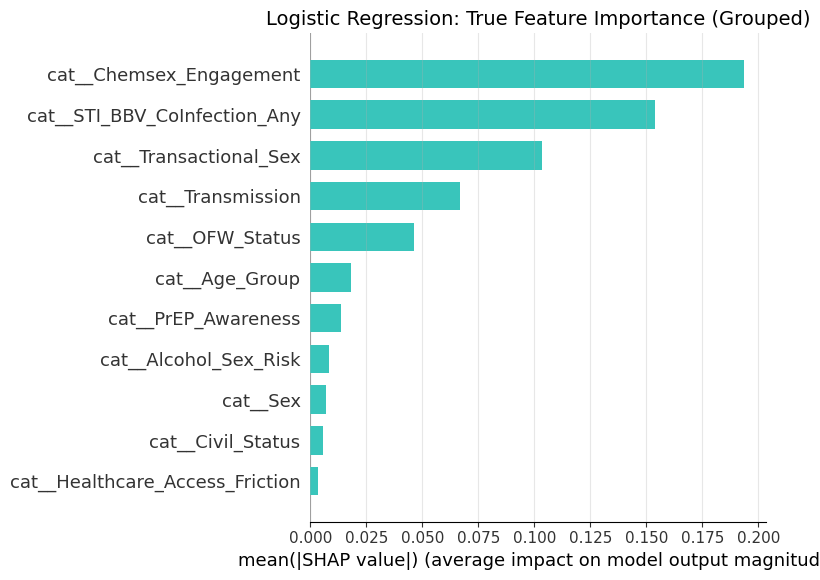

In [12]:
# 4. Plot the Global Feature Importance (Miku Teal!)
plt.figure(figsize=(12, 8))
plt.title("Logistic Regression: True Feature Importance (Grouped)", fontsize=14)

shap.summary_plot(
    grouped_shap_df_lr.values,
    feature_names=grouped_shap_df_lr.columns,
    plot_type="bar",
    color="#39C5BB",  #Turquoise
    show=False
)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## TOP 10 INDIVIDUAL FEATURES 

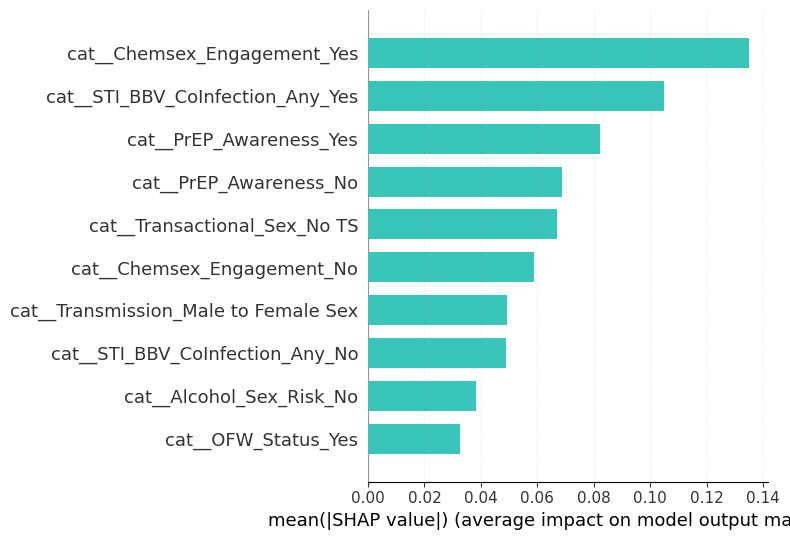

In [13]:
# 1. Calculate SHAP values
explainer_lr = shap.LinearExplainer(best_lr_model, X_train_processed)
shap_vals_lr = explainer_lr.shap_values(X_test_processed)

# 2.(Just in case it returns a list!)
if isinstance(shap_vals_lr, list):
    shap_raw_lr = shap_vals_lr[1]
else:
    shap_raw_lr = shap_vals_lr

# 3. The Plot
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_raw_lr,                           
    features=X_test_processed,
    feature_names=X_test_processed.columns,
    plot_type="bar",                        
    color="#39C5BB",                         # Miku Teal!
    max_display=10,                          # Top 10 only
    show=False
)

# Optional: Adding a subtle grid
plt.grid(axis='x', color='gray', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()

## Beeswarm

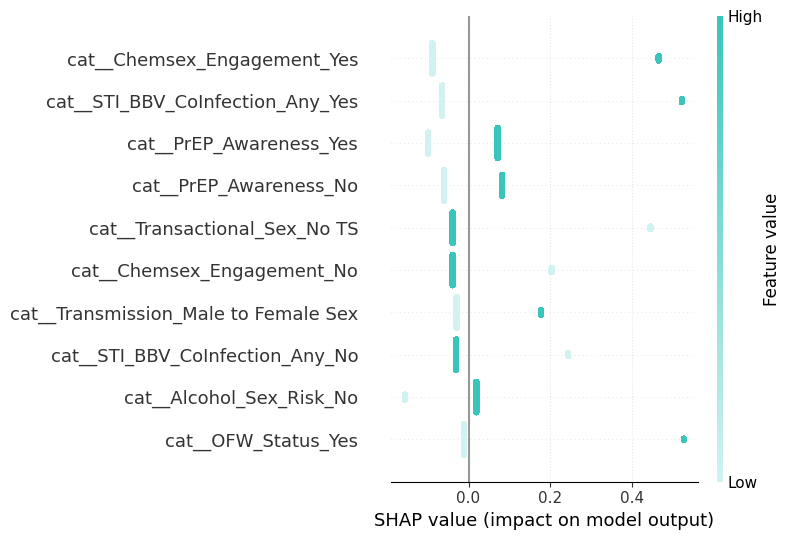

In [14]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# 1. Set up the Miku gradient
miku_cmap = mcolors.LinearSegmentedColormap.from_list("miku_gradient", ["#D1F2F0", "#39C5BB"])

# 2. Create the canvas 
plt.figure(figsize=(10, 6))

# 3. Draw the plot
shap.summary_plot(
    shap_vals_lr,                            # (Or shap_raw_lr if you used the safety check!)
    features=X_test_processed,
    feature_names=X_test_processed.columns,
    plot_type="dot",                         # Beeswarm style
    cmap=miku_cmap,
    max_display=10,                          # Top 10 only
    show=False
)

# Optional: Adding a subtle grid
plt.grid(axis='x', color='gray', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()

# SAVING THE MODEL (RUN MO TO YA IF YOU THINK MAGANDA RESULT PARA MASAVE)

In [15]:
import json
import joblib

print("Saving Logistic Regression artifacts...")

# 1. Save the Scikit-Learn model using Joblib
joblib.dump(best_lr_model, "best_lr_model.joblib")
print("✓ Logistic Regression model saved as 'best_lr_model.joblib'")

# 2. Save the optimal threshold into a small config file
lr_threshold_config = {"best_threshold_lr": float(best_threshold_lr)}
with open("lr_threshold_config.json", "w") as f:
    json.dump(lr_threshold_config, f)
print("✓ Optimal threshold saved as 'lr_threshold_config.json'")

# 3. Save your preprocessors! (If you haven't already)
# If you used an OrdinalEncoder or StandardScaler, you must save them too:
# joblib.dump(encoder, "ordinal_encoder.joblib")
# joblib.dump(scaler, "standard_scaler.joblib") # (If you scaled your data for LR)

print("All artifacts saved successfully!")

Saving Logistic Regression artifacts...
✓ Logistic Regression model saved as 'best_lr_model.joblib'
✓ Optimal threshold saved as 'lr_threshold_config.json'
All artifacts saved successfully!


# Reloading

In [ ]:
import json
import joblib
import pandas as pd
import numpy as np

print("Loading Logistic Regression artifacts...")

# 1. Load the Preprocessors (Encoder / Scaler)
# loaded_encoder = joblib.load("ordinal_encoder.joblib")
# loaded_scaler = joblib.load("standard_scaler.joblib") 

# 2. Load the Threshold
with open("lr_threshold_config.json", "r") as f:
    loaded_config = json.load(f)
loaded_lr_threshold = loaded_config["best_threshold_lr"]

# 3. Load the Logistic Regression Model
loaded_lr_model = joblib.load("best_lr_model.joblib")

print(f"✓ Everything loaded! Operating Threshold: {loaded_lr_threshold:.4f}")

# ==========================================
# HOW TO PREDICT ON BRAND NEW DATA
# ==========================================
# Assuming 'new_patient_data' is a pandas DataFrame with raw data

# A. Transform the new data exactly like you did during training
# new_data_encoded = loaded_encoder.transform(new_patient_data)
# new_data_processed = loaded_scaler.transform(new_data_encoded) # If you used a scaler

# B. Get Probabilities from the loaded Logistic Regression model
# new_lr_probs = loaded_lr_model.predict_proba(new_data_processed)[:, 1]

# C. Apply the Golden Threshold!
# final_lr_predictions = (new_lr_probs >= loaded_lr_threshold).astype(int)

# Optional: Print out the final decisions
# print(final_lr_predictions)